<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

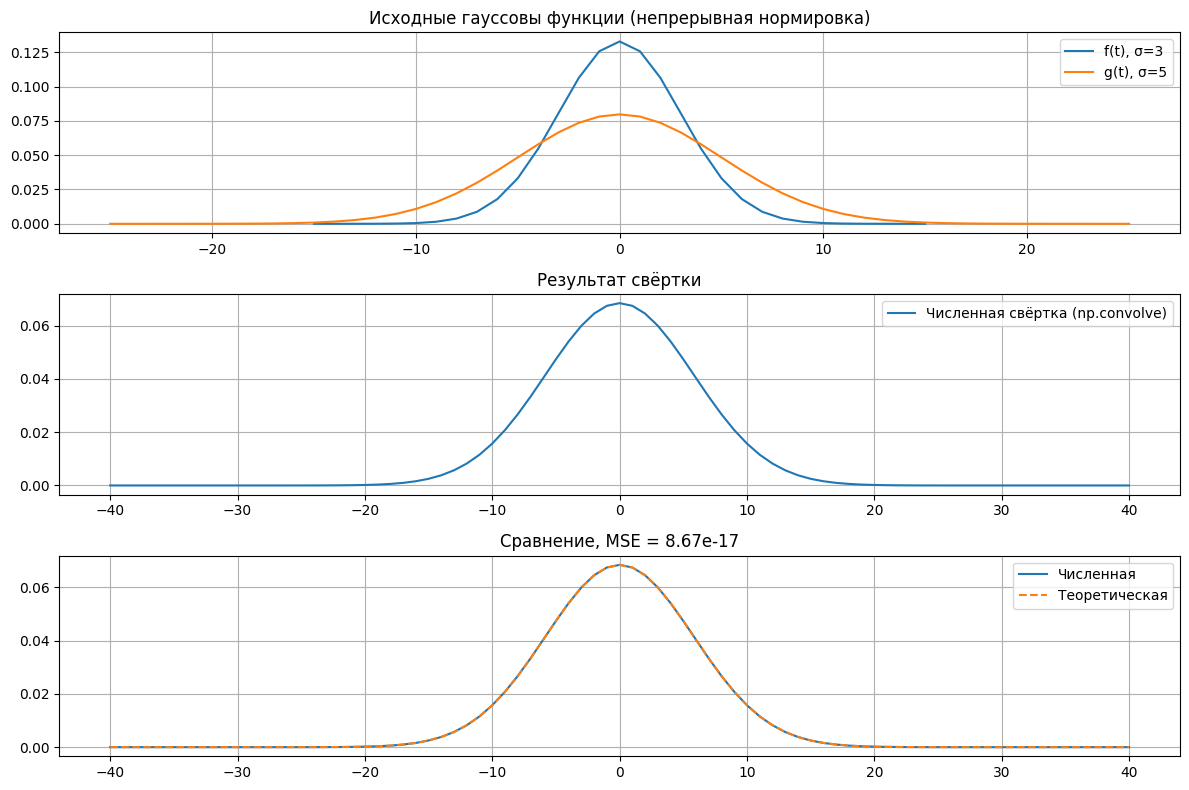

σ_comb = 5.831
MSE = 8.67e-17


In [69]:
sigma1, sigma2 = 3, 5
M1 = 10 * sigma1 + 1
M2 = 10 * sigma2 + 1

t1 = np.arange(M1) - M1 // 2
t2 = np.arange(M2) - M2 // 2


f = 1 / (np.sqrt(2 * np.pi) * sigma1) * np.exp(-t1**2 / (2 * sigma1**2))
g = 1 / (np.sqrt(2 * np.pi) * sigma2) * np.exp(-t2**2 / (2 * sigma2**2))

conv_num = np.convolve(f, g, mode='full')

t_conv = np.arange(len(conv_num)) - (M1 // 2 + M2 // 2)

sigma_comb = np.sqrt(sigma1**2 + sigma2**2)
conv_theory = 1 / (np.sqrt(2 * np.pi) * sigma_comb) * np.exp(-t_conv**2 / (2 * sigma_comb**2))

mse = np.mean((conv_num - conv_theory)**2)


plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t1, f, label=f'f(t), σ={sigma1}')
plt.plot(t2, g, label=f'g(t), σ={sigma2}')
plt.title('Исходные гауссовы функции (непрерывная нормировка)')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_conv, conv_num, label='Численная свёртка (np.convolve)')
plt.title('Результат свёртки')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_conv, conv_num, label='Численная')
plt.plot(t_conv, conv_theory, '--', label='Теоретическая')
plt.title(f'Сравнение, MSE = {mse:.2e}')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f'σ_comb = {sigma_comb:.3f}')
print(f'MSE = {mse:.2e}')



**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

При увеличении σ, форма свёртки становится более гладкой, а максимум пика уменьшается

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

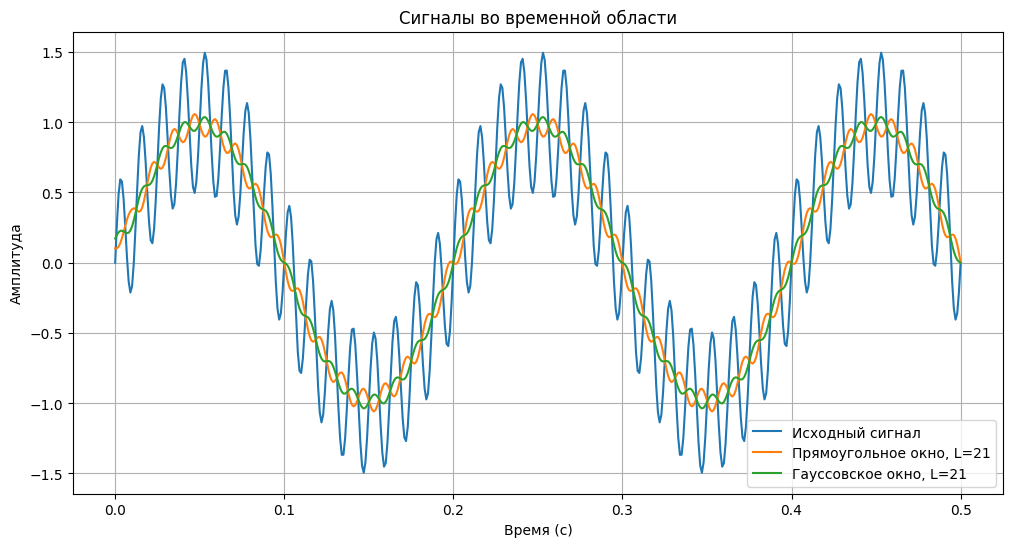

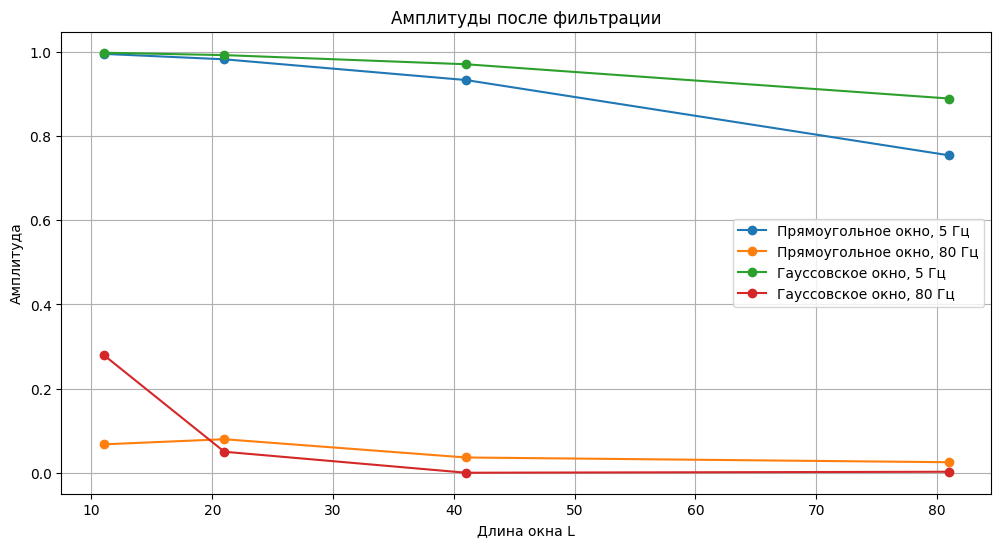

Результаты фильтрации для разных L:
L   | Rect(5 Гц) | Rect(80 Гц) | Gauss(5 Гц) | Gauss(80 Гц)
----|------------|-------------|-------------|-------------
 11 |     0.995  |      0.068  |     0.998   |      0.280 |
 21 |     0.982  |      0.080  |     0.992   |      0.050 |
 41 |     0.933  |      0.037  |     0.970   |      0.000 |
 81 |     0.754  |      0.025  |     0.889   |      0.003 |


In [70]:

fs = 1000
T = 2
t = np.arange(0, T, 1/fs)

f1, A1 = 5, 1.0
f2, A2 = 80, 0.5
x = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.sin(2 * np.pi * f2 * t)

L_values = [11, 21, 41, 81]

rect_amp_5 = []
rect_amp_80 = []
gauss_amp_5 = []
gauss_amp_80 = []

demo_L = 21

def fft_amplitude(sig, freq, fs):
    n = len(sig)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    X = np.fft.rfft(sig)
    amp = 2 * np.abs(X) / n
    idx = np.argmin(np.abs(freqs - freq))
    return amp[idx]

for L in L_values:
    h_rect = signal.windows.boxcar(L)
    h_rect = h_rect / np.sum(h_rect)

    h_gauss = signal.windows.gaussian(L, std = L / 5)
    h_gauss = h_gauss / np.sum(h_gauss)

    y_rect = np.convolve(x, h_rect, mode='same')
    y_gauss = np.convolve(x, h_gauss, mode='same')

    rect_amp_5.append(fft_amplitude(y_rect, 5, fs))
    rect_amp_80.append(fft_amplitude(y_rect, 80, fs))
    gauss_amp_5.append(fft_amplitude(y_gauss, 5, fs))
    gauss_amp_80.append(fft_amplitude(y_gauss, 80, fs))

    if L == demo_L:
        y_rect_demo = y_rect
        y_gauss_demo = y_gauss

mask = t <= 0.5

plt.figure(figsize=(12, 6))
plt.plot(t[mask], x[mask], label='Исходный сигнал')
plt.plot(t[mask], y_rect_demo[mask], label=f'Прямоугольное окно, L={demo_L}')
plt.plot(t[mask], y_gauss_demo[mask], label=f'Гауссовское окно, L={demo_L}')
plt.title('Сигналы во временной области')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(L_values, rect_amp_5, 'o-', label='Прямоугольное окно, 5 Гц')
plt.plot(L_values, rect_amp_80, 'o-', label='Прямоугольное окно, 80 Гц')
plt.plot(L_values, gauss_amp_5, 'o-', label='Гауссовское окно, 5 Гц')
plt.plot(L_values, gauss_amp_80, 'o-', label='Гауссовское окно, 80 Гц')
plt.title('Амплитуды после фильтрации')
plt.xlabel('Длина окна L')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.show()

print("Результаты фильтрации для разных L:")
print("L   | Rect(5 Гц) | Rect(80 Гц) | Gauss(5 Гц) | Gauss(80 Гц)")
print("----|------------|-------------|-------------|-------------")
for i, L in enumerate(L_values):
    print(f"{L:3} | {rect_amp_5[i]:9.3f}  | {rect_amp_80[i]:10.3f}  | {gauss_amp_5[i]:9.3f}   | {gauss_amp_80[i]:10.3f} |")


**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

При одинаковой длине гаусовское окно лучше подавляет высокую частоту.

Падение 80 Гц примерно в 10 раз:
- прямоугольное: с L=41;
- гауссовское: с L=21

При росте L подавление 80 Гц усиливается, но 5 Гц тоже уменьшается. Падение 5 Гц больше чем на 10% появляется только при L=81.

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

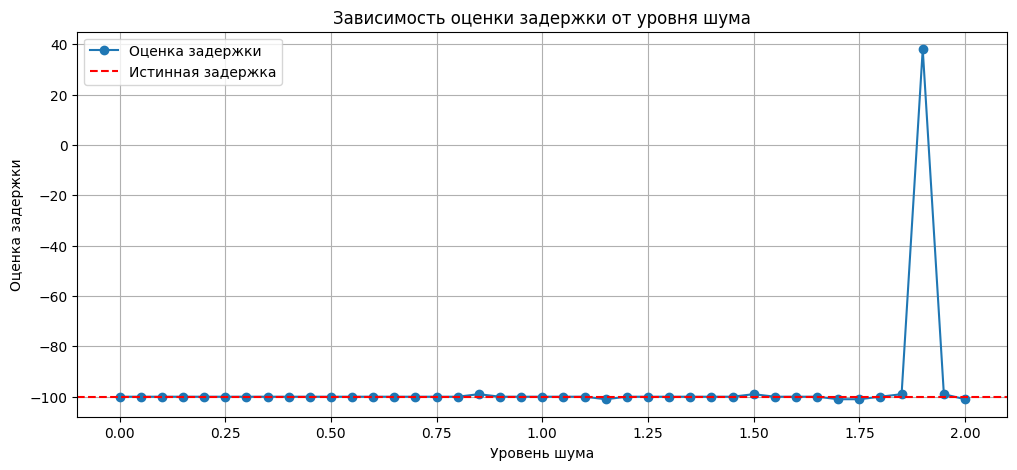

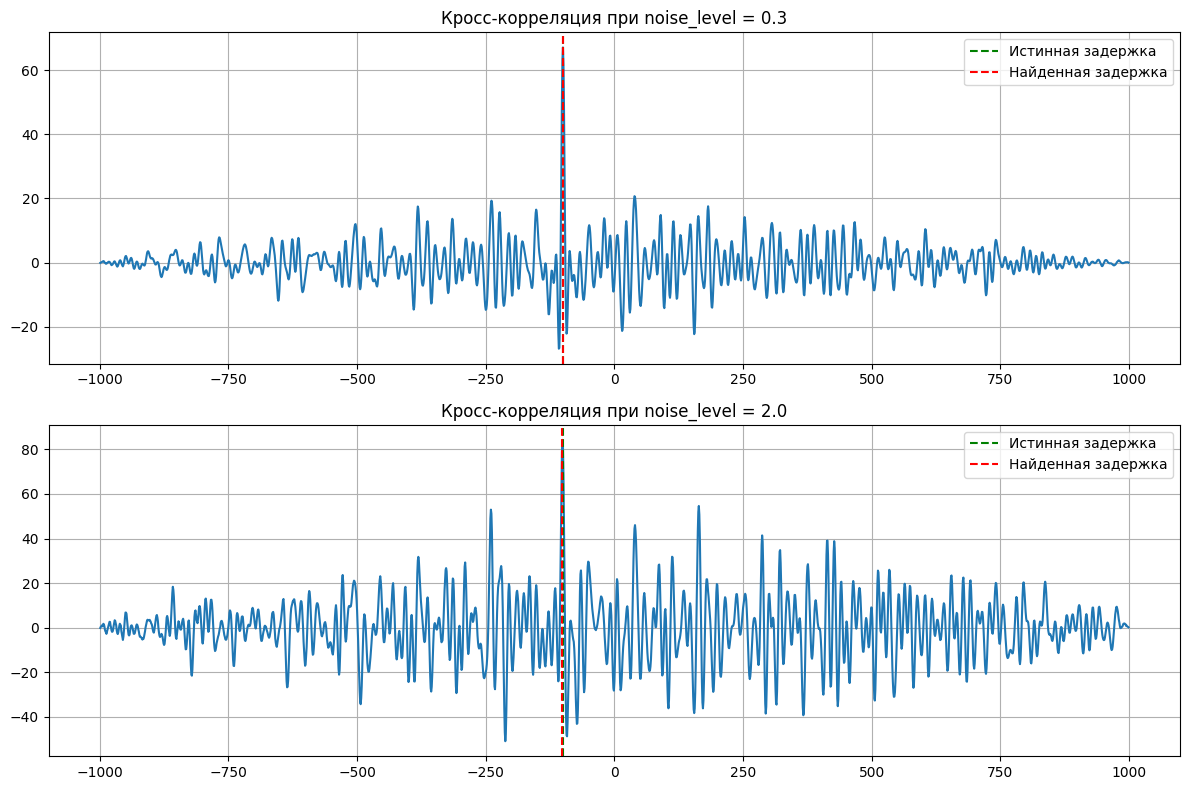

noise_level=0.00, delay_est=-100
noise_level=0.05, delay_est=-100
noise_level=0.10, delay_est=-100
noise_level=0.15, delay_est=-100
noise_level=0.20, delay_est=-100
noise_level=0.25, delay_est=-100
noise_level=0.30, delay_est=-100
noise_level=0.35, delay_est=-100
noise_level=0.40, delay_est=-100
noise_level=0.45, delay_est=-100
noise_level=0.50, delay_est=-100
noise_level=0.55, delay_est=-100
noise_level=0.60, delay_est=-100
noise_level=0.65, delay_est=-100
noise_level=0.70, delay_est=-100
noise_level=0.75, delay_est=-100
noise_level=0.80, delay_est=-100
noise_level=0.85, delay_est=-99
noise_level=0.90, delay_est=-100
noise_level=0.95, delay_est=-100
noise_level=1.00, delay_est=-100
noise_level=1.05, delay_est=-100
noise_level=1.10, delay_est=-100
noise_level=1.15, delay_est=-101
noise_level=1.20, delay_est=-100
noise_level=1.25, delay_est=-100
noise_level=1.30, delay_est=-100
noise_level=1.35, delay_est=-100
noise_level=1.40, delay_est=-100
noise_level=1.45, delay_est=-100
noise_level

In [71]:
np.random.seed(42)

fs = 1000
t = np.arange(0, 1, 1 / fs)

freqs = np.random.uniform(10, 100, 100)
amps = np.random.uniform(0.5, 1.5, 100)
phases = np.random.uniform(0, 2 * np.pi, 100)

x = np.zeros_like(t)
for f, a, p in zip(freqs, amps, phases):
    x += a * np.sin(2 * np.pi * f * t + p)

x = x / np.max(np.abs(x))

delay = 100
true_delay = -delay
noise_levels = np.linspace(0, 2, 41)

delay_estimates = []
errors = []
corr_examples = {}

for noise_level in noise_levels:
    y = np.concatenate([np.zeros(delay), x[:-delay]])
    y = y + noise_level * np.random.randn(len(x))

    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-len(x) + 1, len(x))
    delay_est = lags[np.argmax(corr)]

    delay_estimates.append(delay_est)
    errors.append(abs(delay_est - true_delay))

    if np.isclose(noise_level, 0.3) or np.isclose(noise_level, 2.0):
        corr_examples[round(noise_level, 1)] = (lags, corr, delay_est)

plt.figure(figsize=(12, 5))
plt.plot(noise_levels, delay_estimates, 'o-', label='Оценка задержки')
plt.axhline(true_delay, color='r', linestyle='--', label='Истинная задержка')
plt.xlabel('Уровень шума')
plt.ylabel('Оценка задержки')
plt.title('Зависимость оценки задержки от уровня шума')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
lags, corr, delay_est = corr_examples[0.3]
plt.plot(lags, corr)
plt.axvline(true_delay, color='g', linestyle='--', label='Истинная задержка')
plt.axvline(delay_est, color='r', linestyle='--', label='Найденная задержка')
plt.title('Кросс-корреляция при noise_level = 0.3')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
lags, corr, delay_est = corr_examples[2.0]
plt.plot(lags, corr)
plt.axvline(true_delay, color='g', linestyle='--', label='Истинная задержка')
plt.axvline(delay_est, color='r', linestyle='--', label='Найденная задержка')
plt.title('Кросс-корреляция при noise_level = 2.0')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

for noise_level, delay_est in zip(noise_levels, delay_estimates):
    print(f'noise_level={noise_level:.2f}, delay_est={delay_est}')



**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

Точность оценки задержки убывает с ростом уровня шума. До noise_level = 1.8 оценка остаётся близкой к истинной.

Ошибка больше 10% впервые появляется примерно при noise_level = 1.9.

В диапазоне шума от 0 до 2 оценка не становится неотличимой от 0.

Потому что шум создаёт случайные локальные совпадения, и максимум корреляции может сместиться с истинного положения


## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

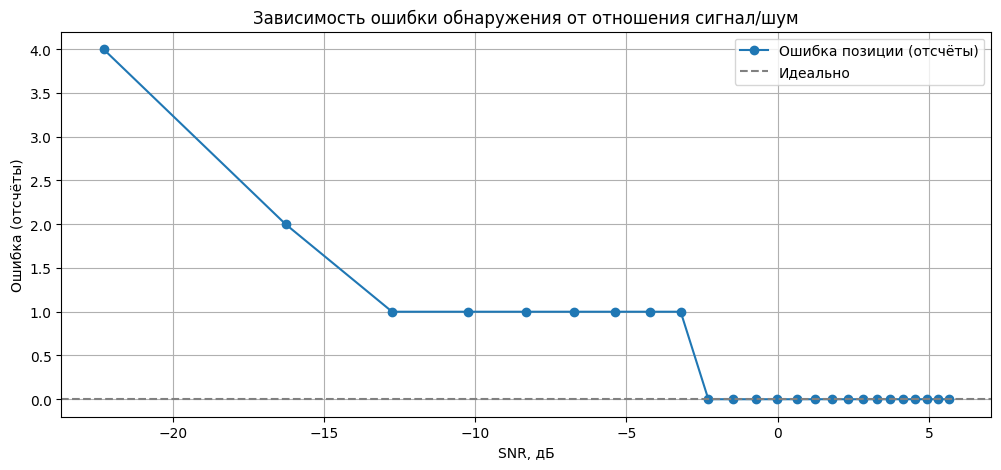

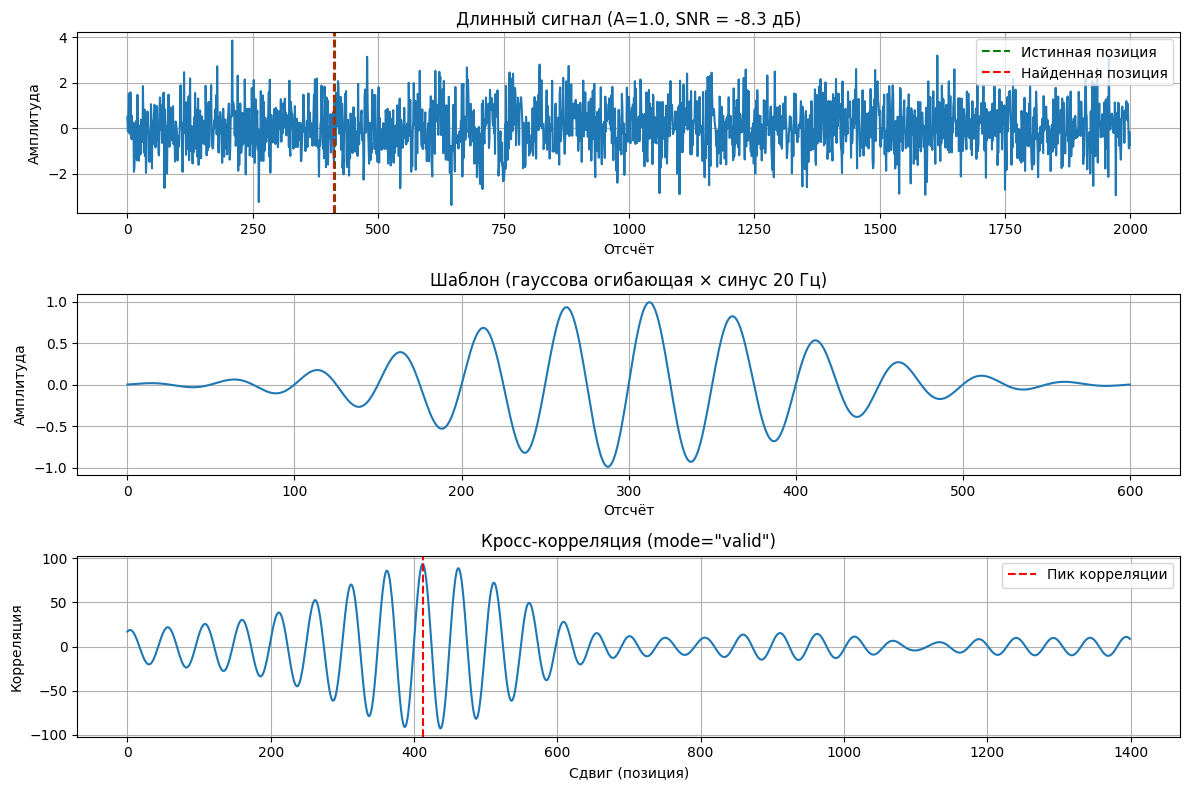

A	SNR (дБ)	Ошибка
0.20	-22.29		4
0.40	-16.27		2
0.60	-12.75		1
0.80	-10.25		1
1.00	-8.31		1
1.20	-6.73		1
1.40	-5.39		1
1.60	-4.23		1
1.80	-3.21		1
2.00	-2.29		0
2.20	-1.46		0
2.40	-0.71		0
2.60	-0.01		0
2.80	0.63		0
3.00	1.23		0
3.20	1.79		0
3.40	2.32		0
3.60	2.81		0
3.80	3.28		0
4.00	3.73		0
4.20	4.15		0
4.40	4.56		0
4.60	4.94		0
4.80	5.31		0
5.00	5.67		0


In [72]:
np.random.seed(42)
fs = 1000
sigma = 100

n_template = 6 * sigma + 1
t_template = np.arange(n_template) - n_template // 2
envelope = np.exp(-t_template**2 / (2 * sigma**2))
template = envelope * np.sin(2 * np.pi * 20 * t_template / fs)

long_len = 2000
amps = np.linspace(0.2, 5.0, 25)
errors = []
snr_vals = []

noise = np.random.randn(long_len)
insert_pos = np.random.randint(0, long_len - len(template) + 1)

for A in amps:
    long_signal = noise.copy()
    long_signal[insert_pos:insert_pos + len(template)] += A * template

    corr = np.correlate(long_signal, template, mode='valid')
    est_pos = np.argmax(corr)

    errors.append(abs(est_pos - insert_pos))
    rms_template = np.sqrt(np.mean(template**2))
    snr_linear = A * rms_template
    snr_vals.append(20 * np.log10(snr_linear))

plt.figure(figsize=(12, 5))
plt.plot(snr_vals, errors, 'o-', label='Ошибка позиции (отсчёты)')
plt.axhline(0, color='gray', linestyle='--', label='Идеально')
plt.xlabel('SNR, дБ')
plt.ylabel('Ошибка (отсчёты)')
plt.title('Зависимость ошибки обнаружения от отношения сигнал/шум')
plt.grid(True)
plt.legend()
plt.show()

example_A = 1.0
long_signal_ex = noise.copy()
long_signal_ex[insert_pos:insert_pos + len(template)] += example_A * template
corr_ex = np.correlate(long_signal_ex, template, mode='valid')
est_pos_ex = np.argmax(corr_ex)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(long_signal_ex)
plt.axvline(insert_pos, color='green', linestyle='--', label='Истинная позиция')
plt.axvline(est_pos_ex, color='red', linestyle='--', label='Найденная позиция')
plt.title(f'Длинный сигнал (A={example_A}, SNR = {20*np.log10(example_A*np.sqrt(np.mean(template**2))):.1f} дБ)')
plt.xlabel('Отсчёт')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(template)
plt.title('Шаблон (гауссова огибающая × синус 20 Гц)')
plt.xlabel('Отсчёт')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(corr_ex)
plt.axvline(est_pos_ex, color='red', linestyle='--', label='Пик корреляции')
plt.title('Кросс-корреляция (mode="valid")')
plt.xlabel('Сдвиг (позиция)')
plt.ylabel('Корреляция')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("A\tSNR (дБ)\tОшибка")
for A, snr, err in zip(amps, snr_vals, errors):
    print(f"{A:.2f}\t{snr:.2f}\t\t{err}")

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

При SNR = -3.21 заметны ухудшения.
Сильные ухудшения возникают при SNR < -12.75


## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [73]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-04-12 19:53:28--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-04-12 19:53:29--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6990446 (6.7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6.67M  --.-KB/s    in 0.02s   

2026-04-12 19:53:29 (300 MB/s) - ‘full_audio.wav’ saved [6990446/69

Фрагмент найден на отсчёте: 279235
Временная метка: 6.332 с


/tmp/ipykernel_7655/3164316430.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_full, full = wavfile.read('full_audio.wav')
/tmp/ipykernel_7655/3164316430.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_frag, frag = wavfile.read('fragment.wav')


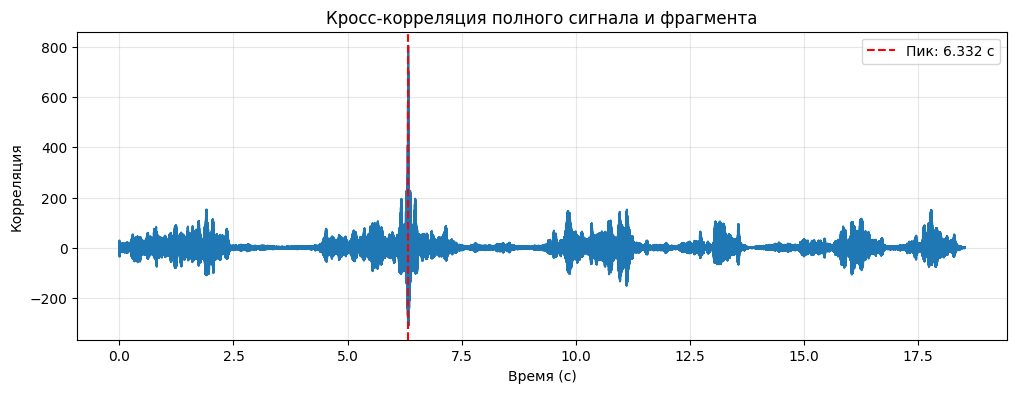

Оригинальный фрагмент:


Найденный участок:


In [74]:

fs_full, full = wavfile.read('full_audio.wav')
fs_frag, frag = wavfile.read('fragment.wav')

if fs_full != fs_frag:
    raise ValueError("Частоты дискретизации не совпадают!")

if full.ndim == 2:
    full = full.mean(axis=1).astype(full.dtype)
if frag.ndim == 2:
    frag = frag.mean(axis=1).astype(frag.dtype)

full = full.astype(np.float64)
frag = frag.astype(np.float64)
full /= np.max(np.abs(full))
frag /= np.max(np.abs(frag))

corr = signal.correlate(full, frag, mode='valid', method='fft')

peak_idx = np.argmax(corr)
peak_time = peak_idx / fs_full

print(f"Фрагмент найден на отсчёте: {peak_idx}")
print(f"Временная метка: {peak_time:.3f} с")

plt.figure(figsize=(12, 4))
time_axis = np.arange(len(corr)) / fs_full
plt.plot(time_axis, corr)
plt.axvline(peak_time, color='r', linestyle='--', label=f'Пик: {peak_time:.3f} с')
plt.title('Кросс-корреляция полного сигнала и фрагмента')
plt.xlabel('Время (с)')
plt.ylabel('Корреляция')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

extracted = full[peak_idx : peak_idx + len(frag)]

print("Оригинальный фрагмент:")
display(Audio(frag, rate=fs_full))

print("Найденный участок:")
display(Audio(extracted, rate=fs_full))

**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

Нормализация переводит аудио в диапазон [-1,1] и делает сравнение сигналов корректным по амплитуде.

Встречается 1 раз на отсчёте 279235, время 6.332с. Ложные максимумы не возникают.

Если фрагмента нет, доминирующего пика не будет.